In [1]:
import numpy as np 
import pickle 
import pandas as pd 
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')
sys.path.append('/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str as format_model_str_utils,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
)

# import aud_dnn.analyze.plot_utils_AUD as plot_utils_AUD

In [2]:
res_path = "/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results/PLOTS_across-models/across-models_barplot_components_NH2015comp_CV-splits-nit-10_median_r2_test_sem_over_it_median_r2_test_performance_sorted.csv"
results_df = pd.read_csv(res_path)
results_df.source_model.unique()

array(['word_kell2018_MatchedDataset_LARS',
       'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
       'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
       'barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_latest_ckpt',
       'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01',
       'spectemp',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lm

In [3]:
def format_model_str(name):
    """Format model name using figure_utils.format_model_str, which handles all the logic."""
    if name == 'spectemp':
        return name
    if name == 'byol-a':
        return name 
    if "whisper" in name.lower():
        return name
    normalized_name, _, _, _ = format_model_str_utils(name)
    return normalized_name

In [4]:
# format_model_str already returns normalized names, so no need to normalize again
results_df['model_name_str'] = results_df.source_model.map(format_model_str)

In [5]:
# Check unique model names after normalization (for debugging)
results_df['model_name_str'].unique()

array(['CochDNN9 supervised word', 'CochDNN9 supervised multi-task',
       'CochDNN9 supervised audioset', 'CochDNN9 ssl λ=0.0',
       'CochDNN9 ssl λ=0.1', 'CochDNN9 ssl λ=0.2', 'CochDNN9 ssl λ=0.3',
       'CochDNN9 ssl λ=0.4', 'CochDNN9 ssl λ=0.5',
       'CochDNN9 ssl dual λ=0.5', 'spectemp', 'CochDNN9 scaled ssl λ=0.5',
       'CochDNN9 scaled ssl λ=0.0', 'CochDNN9 scaled supervised'],
      dtype=object)

In [7]:
def plot_fmri_components(results_df, exclude_pattern="spectemp|dual|1.0", 
                         n_cols=6, figsize=None, show_spectemp_line=True,
                         ylim_offset=0.05, average_over_components=False,
                         model_order=None):
    """
    Plot bar charts for fMRI component predictions across models.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with columns: 'model_name_str', 'comp', 'median_r2_test', 
        'median_r2_test_std_over_it'
    exclude_pattern : str, optional
        Regex pattern for model names to exclude from bars (default: "spectemp|dual|1.0")
    n_cols : int, optional
        Number of columns in subplot grid (default: 6)
    figsize : tuple, optional
        Figure size as (width, height). If None, auto-calculated based on grid.
    show_spectemp_line : bool, optional
        Whether to show spectrotemporal reference line (default: True)
    ylim_offset : float, optional
        Offset below spectemp line for y-axis lower limit (default: 0.05)
    average_over_components : bool, optional
        If True, plot a single panel showing average across all components (default: False)
    model_order : list, optional
        Custom list of model names to plot and their order. If None, uses standard order
        plus any additional models found in the data.
    
    Returns
    -------
    fig, axes : matplotlib figure and axes (axes is a single Axes if average_over_components=True)
    """
    # Filter data for plotting
    to_plot = results_df[~results_df.model_name_str.str.contains(exclude_pattern)]
    
    # Build model order - use custom if provided, otherwise standard + any extra models in data
    all_models_in_data = to_plot['model_name_str'].unique()
    if model_order is not None:
        # Use custom order, filter to models actually in data
        model_order = [m for m in model_order if m in all_models_in_data]
    else:
        # Start with standard order, filter to models in data
        std_order = get_standard_hue_order()
        model_order = [m for m in std_order if m in all_models_in_data]
        # Add any models in data that aren't in standard order
        extra_models = [m for m in all_models_in_data if m not in model_order]
        model_order = model_order + extra_models
    
    # Build palette
    base_colors = get_standard_base_colors()
    hue_dict = build_model_palette(model_order, base_colors)
    hue_dict['byol-a'] = "k"
    # Add palette for whisper models from Oranges palette
    whisper_models = [m for m in model_order if m.lower().startswith("whisper")]
    if whisper_models:
        whisper_colors = sns.color_palette('Oranges', n_colors=max(len(whisper_models), 2))
        for i, name in enumerate(whisper_models):
            hue_dict[name] = whisper_colors[i % len(whisper_colors)]
    # Get spectrotemporal values for reference line
    spectemp_vals = results_df[results_df.model_name_str.str.contains("spectemp")]
    
    # Helper function to create x-axis labels
    def get_x_labels(hue_order):
        x_labels = []
        for name in hue_order:
            label = model_label(name)
            if 'scaled ssl' in name:
                if label.startswith('λ='):
                    lambda_val = label.replace('λ=', '')
                    x_labels.append(f"scaled ssl λ={lambda_val}")
                else:
                    x_labels.append(f"scaled ssl {label}")
            elif 'ssl' in name and 'scaled' not in name:
                if label.startswith('λ='):
                    lambda_val = label.replace('λ=', '')
                    x_labels.append(f"ssl λ={lambda_val}")
                else:
                    x_labels.append(f"ssl {label}")
            else:
                x_labels.append(label)
        return x_labels
    
    # Average over components mode - single panel
    if average_over_components:
        if figsize is None:
            figsize = (4, 4)
        
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        # Calculate average across components for each model
        avg_data = to_plot.groupby('model_name_str').agg({
            'median_r2_test': 'mean',
            'median_r2_test_std_over_it': 'mean'
        }).reset_index()
        
        # Remove duplicates
        avg_data = avg_data.drop_duplicates(subset=['model_name_str'], keep='first')
        
        # Reorder by model order
        avg_data = avg_data.set_index('model_name_str').loc[model_order].reset_index()
        
        # Get the sorted order
        avg_hue_order = avg_data['model_name_str'].values
        
        # Create x positions
        x_pos = np.arange(len(avg_hue_order))
        
        # Get colors for each model
        colors = [hue_dict.get(name, '#444444') for name in avg_hue_order]
        
        # Create barplot
        bar_width = 0.8
        ax.bar(x_pos, avg_data['median_r2_test'].values, width=bar_width, 
               color=colors, edgecolor='black', linewidth=0.5, zorder=0)
        
        # Add error bars
        errors = avg_data['median_r2_test_std_over_it'].values
        ax.errorbar(x_pos, avg_data['median_r2_test'].values, yerr=errors, 
                    fmt='none', color='black', capsize=0, capthick=1, elinewidth=1, zorder=4)
        
        # Add spectrotemporal reference line (average across components)
        if show_spectemp_line and len(spectemp_vals) > 0:
            spectemp_avg = spectemp_vals.groupby('comp')['median_r2_test'].first().mean()
            ax.axhline(spectemp_avg, color='k', linestyle='--', linewidth=1.5, zorder=5, label='spectemp')
            ax.set_ylim(spectemp_avg - ylim_offset, 1)
        
        # Set labels and title
        ax.set_title('Average over components')
        ax.set_ylabel('mean over median $R^2$')
        ax.set_xlabel('')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(get_x_labels(avg_hue_order), rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
        
        # Add legend
        handles, labels = ax.get_legend_handles_labels()
        if any('spectemp' in label for label in labels):
            ax.legend(loc='upper right', frameon=False)
        
        plt.tight_layout()
        return fig, ax
    
    # Per-component mode - multiple subplots
    # Get unique components
    components = to_plot['comp'].unique()
    
    # Create figure with subplots for each component
    n_components = len(components)
    n_rows = (n_components + n_cols - 1) // n_cols
    
    if figsize is None:
        figsize = (20, 3 * n_rows)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_components == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, component in enumerate(components):
        ax = axes[idx]
        
        # Filter data for this component
        comp_data = to_plot[to_plot['comp'] == component].copy()
        
        # Remove duplicates - keep first occurrence of each model_name_str
        comp_data = comp_data.drop_duplicates(subset=['model_name_str'], keep='first')
        
        # Use model order for this component
        comp_data = comp_data.set_index('model_name_str').loc[model_order].reset_index()
        
        # Get the sorted order for this component
        comp_hue_order = comp_data['model_name_str'].values
        
        # Create x positions
        x_pos = np.arange(len(comp_hue_order))
        
        # Get colors for each model
        colors = [hue_dict.get(name, '#444444') for name in comp_hue_order]
        
        # Create barplot with styling matching plot_grouped_bars
        bar_width = 0.8
        bars = ax.bar(x_pos, comp_data['median_r2_test'].values, width=bar_width, 
                      color=colors, edgecolor='black', linewidth=0.5, zorder=0)
        
        # Add error bars (vertical lines) using median_r2_test_std_over_it
        errors = comp_data['median_r2_test_std_over_it'].values
        ax.errorbar(x_pos, comp_data['median_r2_test'].values, yerr=errors, 
                    fmt='none', color='black', capsize=0, capthick=1, elinewidth=1, zorder=4)
        
        # Add spectrotemporal reference line
        if show_spectemp_line and len(spectemp_vals) > 0:
            spectemp_row = spectemp_vals[spectemp_vals.comp == component]
            if len(spectemp_row) > 0:
                spectemp_med = spectemp_row['median_r2_test'].values[0]
                ax.axhline(spectemp_med, color='k', linestyle='--', linewidth=1.5, zorder=5, label='spectemp')
                ax.set_ylim(spectemp_med - ylim_offset, 1)
        
        # Set labels and title
        ax.set_title(f'{component}')
        if idx == 0 or idx == n_cols:
            ax.set_ylabel('median $R^2$')
        ax.set_xlabel('')
        ax.set_xticks(x_pos)
        
        # Create x-axis labels using helper function
        ax.set_xticklabels(get_x_labels(comp_hue_order), rotation=45, ha='right')
        
        ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
    
    # Hide extra subplots if any
    for idx in range(n_components, len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend for spectemp dashed line
    handles, labels = axes[0].get_legend_handles_labels()
    if any('spectemp' in label or 'Spectrotemporal' in label for label in labels):
        axes[0].legend(loc='upper right', frameon=False)
    
    return fig, axes

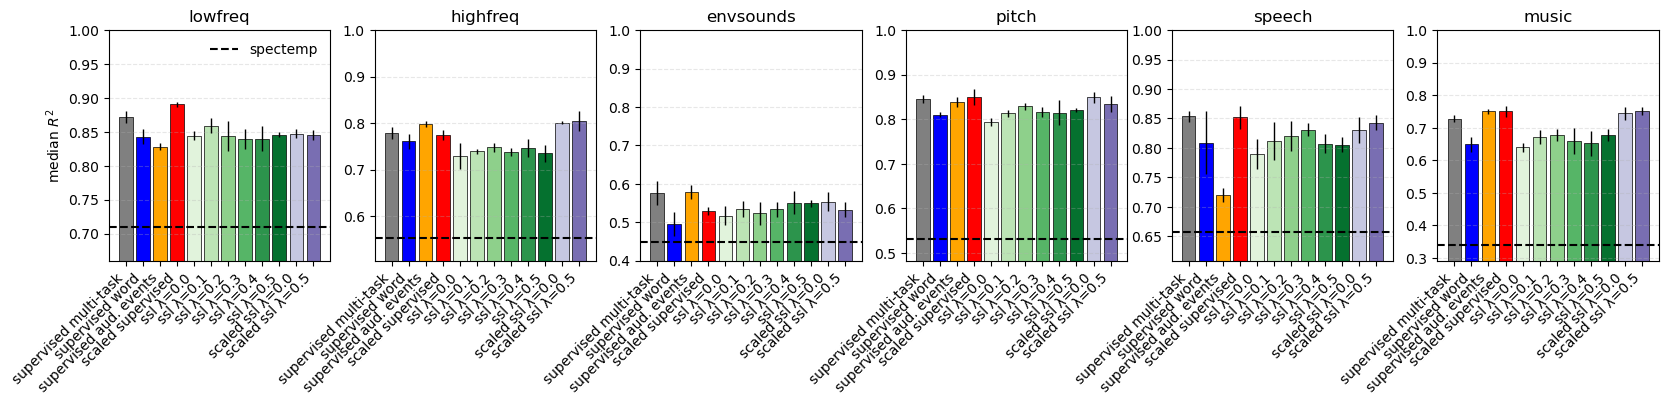

In [8]:
# Example usage with the existing results_df
fig, axes = plot_fmri_components(results_df)

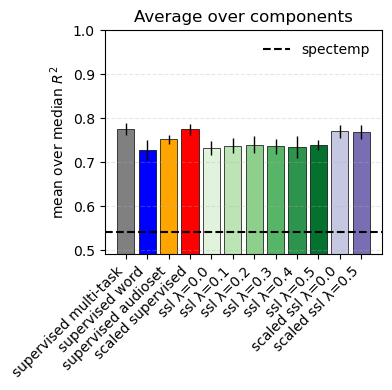

In [157]:
fig, axes = plot_fmri_components(results_df, average_over_components=True)

## Plot BYOL-A and Whisper

In [105]:
fmri_eval_dir = Path("/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results/PLOTS_across-models/")
fname = "across-models_barplot_components_NH2015comp_CV-splits-nit-10_median_r2_test_sem_over_it_median_r2_test_performance_sorted_whisper_models.csv"

whisper_byola_df = pd.read_csv(fmri_eval_dir / fname)

In [140]:
whisper_byola_df['model_name_str'] = whisper_byola_df['source_model'].map(format_model_str)

In [148]:
whisper_byola_df['source_model'].unique()

array(['whisper_tiny.en', 'whisper_medium', 'whisper_large-v3',
       'whisper_large-v3-turbo', 'Kell2018multitask', 'ResNet50multitask',
       'byol-a',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
       'spectemp'], dtype=object)

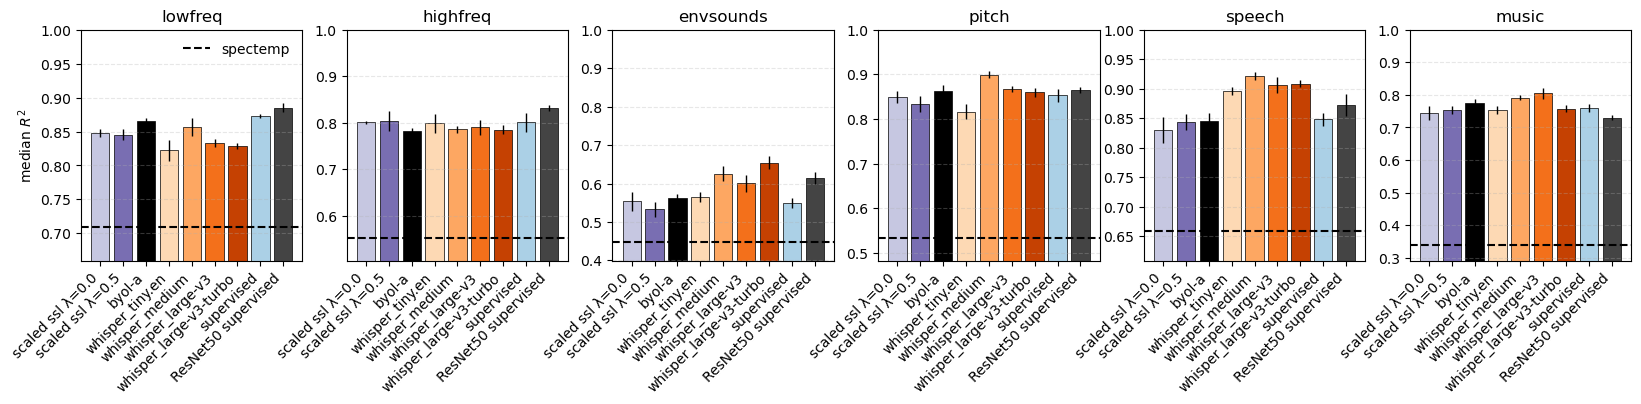

In [147]:
fig, axes = plot_fmri_components(whisper_byola_df)